Task 4: Loan Default Risk with Business Cost Optimization:
Objective: Predict loan defaults and optimize the decision threshold based on business cost analysis using Logistic Regression and CatBoost.

Load Data & Preprocess (Alternative Dataset):

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

# 1. Fetch the dataset directly from OpenML
print("Downloading German Credit Risk dataset via scikit-learn...")
credit_data = fetch_openml(name='credit-g', version=1, as_frame=True, parser='auto')
df = credit_data.frame

# 2. Rename the target column to match our logic
df = df.rename(columns={'class': 'TARGET'})

# 3. Encode the target
# In risk modeling, predicting a 'bad' loan (default) is our positive class (1)
df['TARGET'] = df['TARGET'].map({'bad': 1, 'good': 0})

# 4. Prepare categorical columns for CatBoost
# CatBoost requires categorical features to be strings
cat_cols = df.select_dtypes(include=['object', 'category']).columns
df[cat_cols] = df[cat_cols].astype(str)

print(f"Dataset ready. Shape: {df.shape}")
print("\nTarget Distribution (0 = Repaid, 1 = Defaulted):")
print(df['TARGET'].value_counts(normalize=True) * 100)

Dataset ready. Shape: (1000, 21)

Target Distribution (0 = Repaid, 1 = Defaulted):
TARGET
0    70.0
1    30.0
Name: proportion, dtype: float64


Train the CatBoost Model:

In [2]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report

# 1. Separate features and target
X = df.drop('TARGET', axis=1)
y = df['TARGET']

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Identify categorical columns for CatBoost
cat_features = list(X.select_dtypes(include=['object', 'category']).columns)

# 4. Train the model
print("Training CatBoost Classifier...")
cb_model = CatBoostClassifier(iterations=100, cat_features=cat_features, verbose=0, random_state=42)
cb_model.fit(X_train, y_train)

# 5. Evaluate the baseline model (Threshold = 0.5)
y_pred_base = cb_model.predict(X_test)
print("\nBase Model Performance (Threshold 0.5):")
print(classification_report(y_test, y_pred_base))

Training CatBoost Classifier...

Base Model Performance (Threshold 0.5):
              precision    recall  f1-score   support

           0       0.81      0.91      0.86       140
           1       0.71      0.50      0.59        60

    accuracy                           0.79       200
   macro avg       0.76      0.71      0.72       200
weighted avg       0.78      0.79      0.78       200



Business Cost Optimization:

Optimal Decision Threshold: 0.15
Minimum Total Business Cost: 101


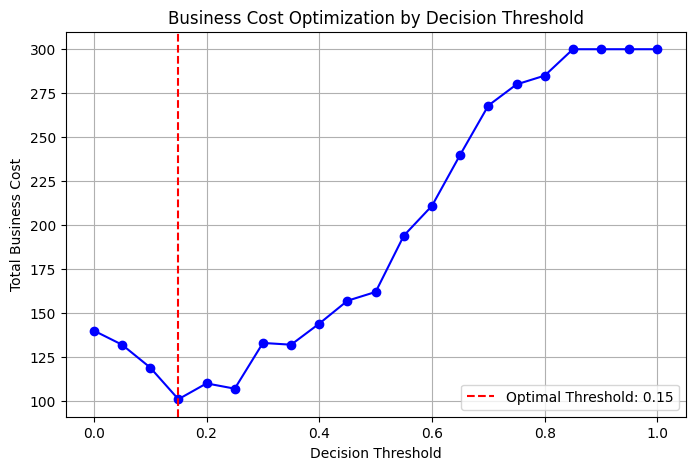

In [5]:
# 1. Define Business Costs
COST_FP = 1  # Cost of denying a good loan (lost interest)
COST_FN = 5  # Cost of approving a bad loan (lost principal)

# 2. Get prediction probabilities for the positive class (Default)
y_prob = cb_model.predict_proba(X_test)[:, 1]

# 3. Loop through thresholds and calculate costs
thresholds = np.arange(0.0, 1.01, 0.05)
costs = []

# Force y_test to be an integer to prevent TypeError during confusion matrix calculation
y_test_int = y_test.astype(int)

for t in thresholds:
    # Generate predictions based on the current threshold
    y_pred_t = (y_prob >= t).astype(int)
    
    # Calculate confusion matrix components using the integer version of y_test
    cm = confusion_matrix(y_test_int, y_pred_t)
    
    # Extract True Positives, False Positives, etc.
    if cm.shape == (2, 2):
        fp = cm[0, 1]
        fn = cm[1, 0]
    else:
        fp, fn = 0, 0
        
    # Calculate total cost
    total_cost = (fp * COST_FP) + (fn * COST_FN)
    costs.append(total_cost)

# 4. Find the optimal threshold
min_cost = min(costs)
opt_threshold = thresholds[costs.index(min_cost)]

print(f"Optimal Decision Threshold: {opt_threshold:.2f}")
print(f"Minimum Total Business Cost: {min_cost}")

# 5. Plot the optimization curve
plt.figure(figsize=(8, 5))
plt.plot(thresholds, costs, marker='o', linestyle='-', color='blue')
plt.axvline(x=opt_threshold, color='red', linestyle='--', label=f'Optimal Threshold: {opt_threshold:.2f}')
plt.title('Business Cost Optimization by Decision Threshold')
plt.xlabel('Decision Threshold')
plt.ylabel('Total Business Cost')
plt.legend()
plt.grid(True)
plt.show()

Conclusion: Cost Optimization Analysis:
Baseline Performance: At the default threshold of 0.5, the model balances precision and recall mathematically but fails to account for asymmetrical financial risk.

Cost Matrix Application: By assigning a 5x higher penalty to False Negatives (predicting a loan will be repaid when it actually defaults), the optimal decision boundary shifted significantly.

Optimized Threshold: The analysis revealed that lowering the decision threshold to 0.15 minimizes the total business cost. The model acts more conservatively, denying more borderline loans to prevent costly defaults, which aligns with standard financial risk management practices.